In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt 
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Any results you write to the current directory are saved as output.

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


In [2]:
train_df = pd.read_csv("/kaggle/input/nlp-getting-started/train.csv")
test_df = pd.read_csv("/kaggle/input/nlp-getting-started/test.csv")

### A quick look at our data

Let's look at our data... first, an example of what is NOT a disaster tweet.**

In [3]:
train_df[~train_df.keyword.isnull()].head()

,id,keyword,location,text,target
31,48,ablaze,Birmingham,@bbcmtd Wholesale Markets ablaze http://t.co/l...,1
32,49,ablaze,Est. September 2012 - Bristol,We always try to bring the heavy. #metal #RT h...,0
33,50,ablaze,AFRICA,#AFRICANBAZE: Breaking news:Nigeria flag set a...,1
34,52,ablaze,"Philadelphia, PA",Crying out for more! Set me ablaze,0
35,53,ablaze,"London, UK",On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0


### How many unique keywords are there in disaster tweets?

In [4]:
train_df[train_df.target == 1 & ~train_df.keyword.isnull()].keyword.nunique()

220

### What are the most frequently occuring disaster keywords?

In [5]:
df = train_df[train_df.target == 1 & ~train_df.keyword.isnull()].keyword.value_counts().to_frame('count').reset_index()
df.columns = ['keyword', 'count']
df.head(10)

,keyword,count
0,wreckage,39
1,outbreak,39
2,derailment,39
3,oil%20spill,37
4,debris,37
5,typhoon,37
6,evacuated,32
7,suicide%20bombing,32
8,suicide%20bomb,32
9,rescuers,32


### Normal Tweet examples

In [6]:
train_df[train_df["target"] == 0]["text"].values[1:5]

array(['I love fruits', 'Summer is lovely', 'My car is so fast',
       'What a goooooooaaaaaal!!!!!!'], dtype=object)

### Disaster Tweet examples

In [7]:
train_df[train_df["target"] == 1]["text"].values[1:5]

array(['Forest fire near La Ronge Sask. Canada',
       "All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected",
       '13,000 people receive #wildfires evacuation orders in California ',
       'Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school '],
      dtype=object)

### Class balance check

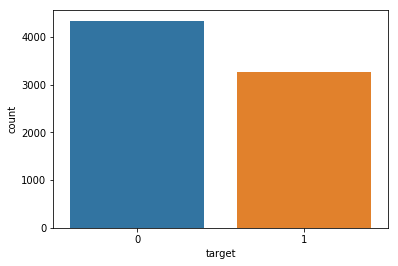

In [8]:
sns.countplot(x='target', data=train_df)

### Training Keyword Distribution

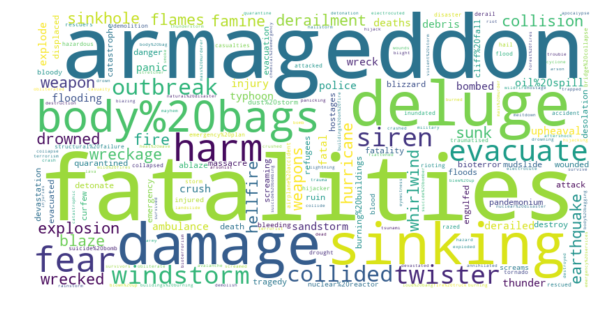

In [9]:
keywords = dict(train_df.keyword.value_counts())
wordcloud = WordCloud(width=800, height=400,background_color="white").generate_from_frequencies(keywords)
plt.figure(figsize=[10,8])
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Test Text distribution

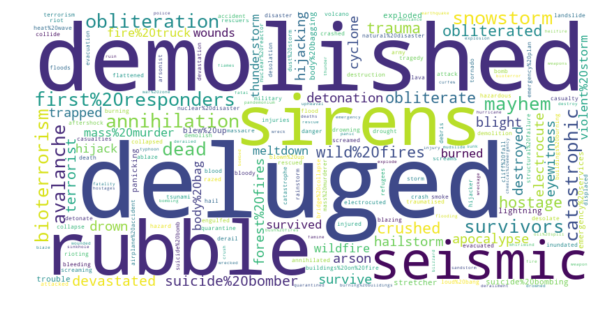

In [10]:
keywords = dict(test_df.keyword.value_counts())
wordcloud = WordCloud(width=800, height=400,background_color="white").generate_from_frequencies(keywords)
plt.figure(figsize=[10,8])
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

### Average character length of tweets

The distribution shows the cap of 140 characters in twitter. However, there is not a significant difference between disaster and a non-disaster tweet.

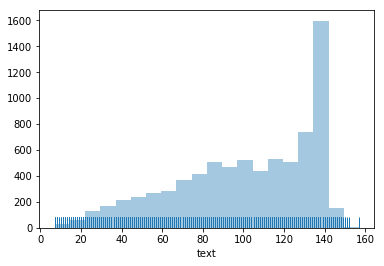

In [11]:
sns.distplot(train_df.text.str.len(), bins=20, kde=False, rug=True);

In [12]:
print("Avg tweet length of no disaster {0}" .format(train_df[train_df.target == 0].text.str.len().mean()))
print("Avg tweet length of disaster {0}" .format(train_df[train_df.target == 1].text.str.len().mean()))

Avg tweet length of no disaster 95.70681713496084
Avg tweet length of disaster 108.11342097217977


### Average word length of tweets : Around 15 words per tweet

In [13]:
def word_length(tweet):
    return len(tweet.split(' '))

In [14]:
train_df['len'] = train_df.text.apply(word_length)

In [15]:
print("Avg word length of no disaster {0}" .format(train_df[train_df.target == 0].len.mean()))
print("Avg word length of disaster {0}" .format(train_df[train_df.target == 1].len.mean()))

Avg word length of no disaster 14.723859972362966
Avg word length of disaster 15.20116172424335


In [16]:
print("Avg word length of a tweet {0}".format(train_df.len.mean()))

Avg word length of a tweet 14.928937344016813


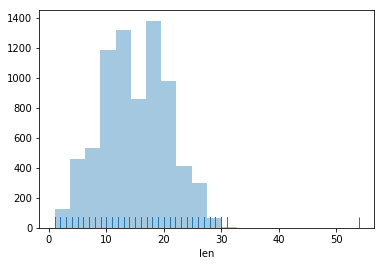

In [17]:
sns.distplot(train_df.len, bins=20, kde=False, rug=True);

## Same words, but different context!

#### Positive ablaze

In [18]:
train_df.text.values[36] #Positive ablaze

"@PhDSquares #mufc they've built so much hype around new acquisitions but I doubt they will set the EPL ablaze this season."

Negative ablaze

In [19]:
train_df.text.values[46] 

'How the West was burned: Thousands of wildfires ablaze in California alone http://t.co/vl5TBR3wbr'